# 📊 Factor Exposure Analyzer

A Python-based tool that analyzes any stock portfolio's exposure to 
the five classic Fama-French risk factors — market, size, value, 
profitability, and investment.

Inspired by institutional factor models like Barra, this tool helps 
answer the most important question in portfolio analysis: are your 
returns driven by skill, or just factor exposure?

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm
import pandas_datareader as pdr

1. `import pandas as pd` - Imports the pandas library with the alias 'pd'. Pandas provides data structures and functions for data manipulation and analysis.

2. `import numpy as np` - Imports the NumPy library with the alias 'np'. NumPy provides support for large, multi-dimensional arrays and mathematical functions.

3. `import yfinance as yf` - Imports the yfinance library with the alias 'yf'. This library allows you to download financial market data from Yahoo Finance.

4. `import statsmodels.api as sm` - Imports the statsmodels API with the alias 'sm'. Statsmodels is a library for statistical modeling and econometrics.

5. `import pandas_datareader as pdr` - Imports the pandas-datareader library with the alias 'pdr'. This library provides functions to extract data from various Internet sources into pandas DataFrames.

In [2]:
start_date = input("Enter start date (YYYY-MM-DD): ")
ff_factors = pdr.get_data_famafrench('F-F_Research_Data_5_Factors_2x3', start=start_date)[0]
ff_factors.index = ff_factors.index.to_timestamp()
ff_factors.index = ff_factors.index.to_period('M')
ff_factors = ff_factors / 100
print(ff_factors.head())
print(ff_factors.tail())

Enter start date (YYYY-MM-DD):  2020-01-01


         Mkt-RF     SMB     HML     RMW     CMA      RF
Date                                                   
2020-01 -0.0009 -0.0437 -0.0622 -0.0119 -0.0219  0.0013
2020-02 -0.0815  0.0008 -0.0382 -0.0143 -0.0253  0.0012
2020-03 -0.1335 -0.0818 -0.1383 -0.0161  0.0119  0.0012
2020-04  0.1358  0.0257 -0.0134  0.0276 -0.0102  0.0000
2020-05  0.0559  0.0192 -0.0500  0.0096 -0.0316  0.0001
         Mkt-RF     SMB     HML     RMW     CMA      RF
Date                                                   
2025-10  0.0196 -0.0131 -0.0310 -0.0524 -0.0403  0.0037
2025-11 -0.0013  0.0147  0.0376  0.0144  0.0068  0.0030
2025-12 -0.0036 -0.0022  0.0242  0.0040  0.0037  0.0034
2026-01  0.0103  0.0326  0.0372  0.0182  0.0183  0.0030
2026-02 -0.0117  0.0063  0.0283  0.0162  0.0507  0.0028


/var/folders/pk/crkrcywx4hl9mvlzshx1tzth0000gn/T/ipykernel_7981/3901094963.py:2: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff_factors = pdr.get_data_famafrench('F-F_Research_Data_5_Factors_2x3', start=start_date)[0]
/var/folders/pk/crkrcywx4hl9mvlzshx1tzth0000gn/T/ipykernel_7981/3901094963.py:2: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff_factors = pdr.get_data_famafrench('F-F_Research_Data_5_Factors_2x3', start=start_date)[0]


1. `start_date = input("Enter start date (YYYY-MM-DD): ")` - Prompts the user to enter a start date in YYYY-MM-DD format and stores it in the variable `start_date`.

2. `ff_factors = pdr.get_data_famafrench('F-F_Research_Data_5_Factors_2x3', start=start_date)[0]` - Uses pandas-datareader to download the Fama-French 5-factor data starting from the user-specified date. The `[0]` selects the first DataFrame returned by the function.

3. `ff_factors.index = ff_factors.index.to_timestamp()` - Converts the index to timestamp format.

4. `ff_factors.index = ff_factors.index.to_period('M')` - Converts the timestamp index to a period index with monthly frequency.

5. `ff_factors = ff_factors / 100` - Divides all values in the DataFrame by 100, likely converting percentage values to decimal format.

6. The last two lines print the first and last few rows of the processed DataFrame.

In [3]:
tickers_input = input("Enter tickers separated by commas (e.g. AAPL, MSFT, NVDA): ")
tickers = [t.strip().upper() for t in tickers_input.split(",")]
print("Portfolio tickers:", tickers)

Enter tickers separated by commas (e.g. AAPL, MSFT, NVDA):  AAPL,AMZN,MSFT,NVDA


Portfolio tickers: ['AAPL', 'AMZN', 'MSFT', 'NVDA']


1. `tickers_input = input("Enter tickers separated by commas (e.g. AAPL, MSFT, NVDA): ")` - This prompts the user to enter stock ticker symbols separated by commas and stores the input as a string in the variable `tickers_input`.

2. `tickers = [t.strip().upper() for t in tickers_input.split(",")]` - This line:
   - Splits the input string at each comma using `split(",")`
   - Uses a list comprehension to process each ticker symbol
   - `t.strip()` removes any whitespace before or after each ticker
   - `.upper()` converts each ticker to uppercase
   - The result is a list of cleaned, uppercase ticker symbols

3. `print("Portfolio tickers:", tickers)` - This prints the processed list of tickers to confirm what was entered.

In [4]:
prices = yf.download(tickers, start=start_date, auto_adjust = False)['Adj Close']
monthly_prices = prices.resample('ME').last()
monthly_returns = monthly_prices.pct_change().dropna()
print(monthly_returns.head())

[*********************100%***********************]  4 of 4 completed

Ticker          AAPL      AMZN      MSFT      NVDA
Date                                              
2020-02-29 -0.114702 -0.062214 -0.045688  0.142966
2020-03-31 -0.069761  0.035021 -0.026541 -0.023957
2020-04-30  0.155374  0.268900  0.136326  0.108801
2020-05-31  0.085094 -0.012785  0.025391  0.214657
2020-06-30  0.147386  0.129567  0.110559  0.070597


1. `prices = yf.download(tickers, start=start_date, auto_adjust=False)['Adj Close']` - Downloads historical stock price data using Yahoo Finance API for the specified tickers starting from start_date. It extracts only the 'Adj Close' (adjusted closing) prices.

2. `monthly_prices = prices.resample('ME').last()` - Resamples the daily price data to monthly frequency, taking the last trading day of each month. 'ME' stands for month end.

3. `monthly_returns = monthly_prices.pct_change().dropna()` - Calculates the percentage change between consecutive months (monthly returns) and removes any rows with missing values.

4. `print(monthly_returns.head())` - Displays the first five rows of the monthly returns DataFrame.

In [5]:
while True:
    weights_input = input(f"Enter weights for {tickers} as whole numbers summing to 100 (e.g. 30.5,40.5,29): ")
    weights = [float(w.strip())/100 for w in weights_input.split(',')]
    
    if len(weights) != len(tickers):
        print(f"❌ Error: You entered {len(weights)} weights but have {len(tickers)} tickers. Try again.")
    elif round(sum(weights), 2) != 1.0:
        print(f"❌ Error: Weights sum to {sum(weights)*100:.2f}%, they must sum to 100%. Try again.")
    else:
        print("\n✅ Portfolio weights confirmed:")
        for ticker, weight in zip(tickers, weights):
            print(f"   {ticker}: {weight*100:.2f}%")
        break

portfolio_returns = monthly_returns.dot(weights)
portfolio_returns.index = portfolio_returns.index.to_period('M')

Enter weights for ['AAPL', 'AMZN', 'MSFT', 'NVDA'] as whole numbers summing to 100 (e.g. 30.5,40.5,29):  25,25,25,25



✅ Portfolio weights confirmed:
   AAPL: 25.00%
   AMZN: 25.00%
   MSFT: 25.00%
   NVDA: 25.00%


1. `while True:` - Creates an infinite loop that will continue until explicitly broken.

2. `weights_input = input(...)` - Prompts the user to enter weights for their portfolio tickers as comma-separated values.

3. `weights = [float(w.strip())/100 for w in weights_input.split(',')]` - Converts the input string to a list of floats:
   - Splits the input string by commas
   - Strips whitespace from each value
   - Converts each value to a float
   - Divides by 100 to convert percentages to decimals

4. The code then performs two validation checks:
   - Checks if the number of weights matches the number of tickers
   - Checks if the weights sum to 1.0 (100%)

5. If either validation fails, an error message is displayed and the loop continues.

6. If validation passes, it:
   - Displays the confirmed portfolio weights
   - Uses `break` to exit the loop

In [6]:
merged = pd.concat([portfolio_returns, ff_factors], axis=1).dropna()
merged.columns = ['Portfolio', 'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']

print(merged.head())
print(f"\nTotal months of data: {len(merged)}")

         Portfolio  Mkt-RF     SMB     HML     RMW     CMA      RF
Date                                                              
2020-02  -0.019909 -0.0815  0.0008 -0.0382 -0.0143 -0.0253  0.0012
2020-03  -0.021310 -0.1335 -0.0818 -0.1383 -0.0161  0.0119  0.0012
2020-04   0.167350  0.1358  0.0257 -0.0134  0.0276 -0.0102  0.0000
2020-05   0.078090  0.0559  0.0192 -0.0500  0.0096 -0.0316  0.0001
2020-06   0.114527  0.0244  0.0195 -0.0217  0.0014  0.0055  0.0001

Total months of data: 73


1. `merged = pd.concat([portfolio_returns, ff_factors], axis=1).dropna()` - This line combines two DataFrames:
   - `portfolio_returns` and `ff_factors` are merged horizontally (axis=1)
   - The `dropna()` method removes any rows with missing values from the combined DataFrame

2. `merged.columns = ['Portfolio', 'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']` - This renames the columns of the merged DataFrame to standard financial factor names:
   - 'Portfolio' (likely portfolio returns)
   - 'Mkt-RF' (market return minus risk-free rate)
   - 'SMB' (Small Minus Big - size factor)
   - 'HML' (High Minus Low - value factor)
   - 'RMW' (Robust Minus Weak - profitability factor)
   - 'CMA' (Conservative Minus Aggressive - investment factor)
   - 'RF' (Risk-Free rate)

3. The code then prints the first 5 rows of the merged DataFrame and the total number of months in the dataset.

In [7]:
Y = merged['Portfolio'] - merged['RF']
X = merged[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']]
X = sm.add_constant(X)

model = sm.OLS(Y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.824
Model:                            OLS   Adj. R-squared:                  0.811
Method:                 Least Squares   F-statistic:                     62.72
Date:                Mon, 06 Apr 2026   Prob (F-statistic):           6.20e-24
Time:                        21:17:24   Log-Likelihood:                 145.29
No. Observations:                  73   AIC:                            -278.6
Df Residuals:                      67   BIC:                            -264.8
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0122      0.004      2.910      0.0

1. `Y = merged['Portfolio'] - merged['RF']` - Creates the dependent variable by calculating the excess return of the portfolio over the risk-free rate.

2. `X = merged[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']]` - Creates the independent variables dataframe containing the five Fama-French factors: market excess return, size factor, value factor, profitability factor, and investment factor.

3. `X = sm.add_constant(X)` - Adds a constant term (intercept) to the independent variables, which represents the alpha in the regression.

4. `model = sm.OLS(Y, X).fit()` - Creates and fits an Ordinary Least Squares regression model using statsmodels, with Y as the dependent variable and X as the independent variables.

5. `print(model.summary())` - Prints a comprehensive summary of the regression results, including coefficients, standard errors, t-statistics, p-values, R-squared, and other regression diagnostics.

In [8]:
params = model.params
pvalues = model.pvalues

def significance(p):
    if p < 0.01:
        return "*** highly significant"
    elif p < 0.05:
        return "** significant"
    elif p < 0.10:
        return "* marginally significant"
    else:
        return "not significant"

print("=" * 55)
print("           FACTOR EXPOSURE REPORT")
print("=" * 55)
print(f"Alpha (monthly):  {params['const']:.4f}  (p={pvalues['const']:.3f})  {significance(pvalues['const'])}")
print(f"Market Beta:      {params['Mkt-RF']:.4f}  (p={pvalues['Mkt-RF']:.3f})  {significance(pvalues['Mkt-RF'])}")
print(f"Size (SMB):       {params['SMB']:.4f}  (p={pvalues['SMB']:.3f})  {significance(pvalues['SMB'])}")
print(f"Value (HML):      {params['HML']:.4f}  (p={pvalues['HML']:.3f})  {significance(pvalues['HML'])}")
print(f"Profitability:    {params['RMW']:.4f}  (p={pvalues['RMW']:.3f})  {significance(pvalues['RMW'])}")
print(f"Investment:       {params['CMA']:.4f}  (p={pvalues['CMA']:.3f})  {significance(pvalues['CMA'])}")
print("-" * 55)
print(f"R-squared:        {model.rsquared:.4f}")
print(f"Adj. R-squared:   {model.rsquared_adj:.4f}")
print(f"Observations:     {int(model.nobs)}")
print("=" * 55)

           FACTOR EXPOSURE REPORT
Alpha (monthly):  0.0122  (p=0.005)  *** highly significant
Market Beta:      1.2398  (p=0.000)  *** highly significant
Size (SMB):       -0.2751  (p=0.091)  * marginally significant
Value (HML):      -0.7046  (p=0.000)  *** highly significant
Profitability:    0.1370  (p=0.447)  not significant
Investment:       -0.1395  (p=0.469)  not significant
-------------------------------------------------------
R-squared:        0.8240
Adj. R-squared:   0.8108
Observations:     73


1. The code extracts model parameters and p-values from a previously fitted statistical model (likely a regression model).

2. It defines a `significance()` function that categorizes p-values into different significance levels:
   - p < 0.01: "*** highly significant"
   - p < 0.05: "** significant" 
   - p < 0.10: "* marginally significant"
   - otherwise: "not significant"

3. It prints a formatted header for the "FACTOR EXPOSURE REPORT".

4. It then prints each factor's coefficient (from `params`), p-value (from `pvalues`), and significance level:
   - Alpha (constant term)
   - Market Beta (Mkt-RF)
   - Size factor (SMB)
   - Value factor (HML)
   - Profitability factor (RMW)
   - Investment factor (CMA)

5. Finally, it prints model quality metrics:
   - R-squared value
   - Adjusted R-squared value
   - Number of observations

In [9]:
monthly_alpha = params['const']
annualized_alpha = (1 + monthly_alpha) ** 12 - 1

print(f"Monthly Alpha:    {monthly_alpha:.4f}  ({monthly_alpha*100:.2f}%)")
print(f"Annualized Alpha: {annualized_alpha:.4f}  ({annualized_alpha*100:.2f}%)")

Monthly Alpha:    0.0122  (1.22%)
Annualized Alpha: 0.1567  (15.67%)


1. `monthly_alpha = params['const']` - Retrieves the monthly alpha value from a dictionary called `params` using the key 'const'.

2. `annualized_alpha = (1 + monthly_alpha) ** 12 - 1` - Converts the monthly alpha to an annualized alpha by:
   - Adding 1 to the monthly alpha
   - Raising this value to the power of 12 (representing 12 months in a year)
   - Subtracting 1 from the result

3. The two print statements format and display both values:
   - First line shows the monthly alpha in decimal and percentage format
   - Second line shows the annualized alpha in decimal and percentage format
   - The formatting (`.4f` and `.2f`) controls the number of decimal places shown

In [10]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

1. `import plotly.graph_objects as go` - This imports the graph_objects module from Plotly and assigns it the alias 'go'. This module contains the core plotting capabilities of Plotly, providing various chart types and visualization objects like scatter plots, bar charts, and more.

2. `from plotly.subplots import make_subplots` - This imports the specific make_subplots function from Plotly's subplots module. This function allows you to create figures with multiple subplots arranged in a grid layout, similar to matplotlib's subplots but with Plotly's interactive features.

These imports are necessary preparation for creating interactive visualizations with Plotly.

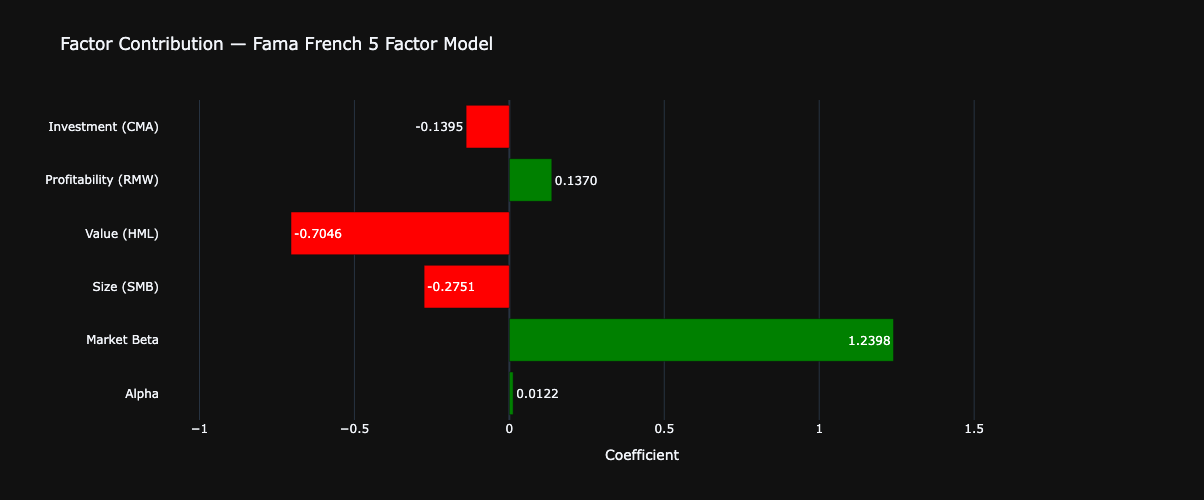

In [11]:
factors = ['Alpha', 'Market Beta', 'Size (SMB)', 'Value (HML)', 'Profitability (RMW)', 'Investment (CMA)']
values = [params['const'], params['Mkt-RF'], params['SMB'], params['HML'], params['RMW'], params['CMA']]
colors = ['green' if v > 0 else 'red' for v in values]

fig1 = go.Figure(go.Bar(
    x=values,
    y=factors,
    orientation='h',
    marker_color=colors,
    text=[f'{v:.4f}' for v in values],
    textposition='auto',
    textfont=dict(size=12)
))

fig1.update_layout(
    title='Factor Contribution — Fama French 5 Factor Model',
    xaxis_title='Coefficient',
    template='plotly_dark',
    height=500,
    xaxis=dict(
        range=[min(values) * 1.6, max(values) * 1.6],
        automargin=True
    ),
    margin=dict(l=160)
)

fig1.show()

1. First, it sets up two lists:
   - `factors`: Names of the six factors in the model (Alpha plus the five Fama-French factors)
   - `values`: The corresponding coefficient values extracted from a `params` object

2. It creates a list of colors based on coefficient values - green for positive values and red for negative values.

3. The `go.Figure()` creates a Plotly figure with a horizontal bar chart:
   - `orientation='h'` makes the bars horizontal
   - `marker_color=colors` applies the red/green color scheme
   - `text=[f'{v:.4f}' for v in values]` formats the coefficient values to 4 decimal places
   - `textposition='auto'` automatically positions the text labels

4. `fig1.update_layout()` customizes the appearance:
   - Sets the chart title and x-axis label
   - Uses the dark theme (`template='plotly_dark'`)
   - Sets a fixed height of 500 pixels
   - Adjusts the x-axis range to be 1.6 times the min/max values for better visualization
   - Adds left margin space (`margin=dict(l=160)`) to accommodate factor labels

5. Finally, `fig1.show()` displays the interactive chart.

This visualization helps to quickly identify which factors have positive or negative contributions to the model and their relative magnitudes.

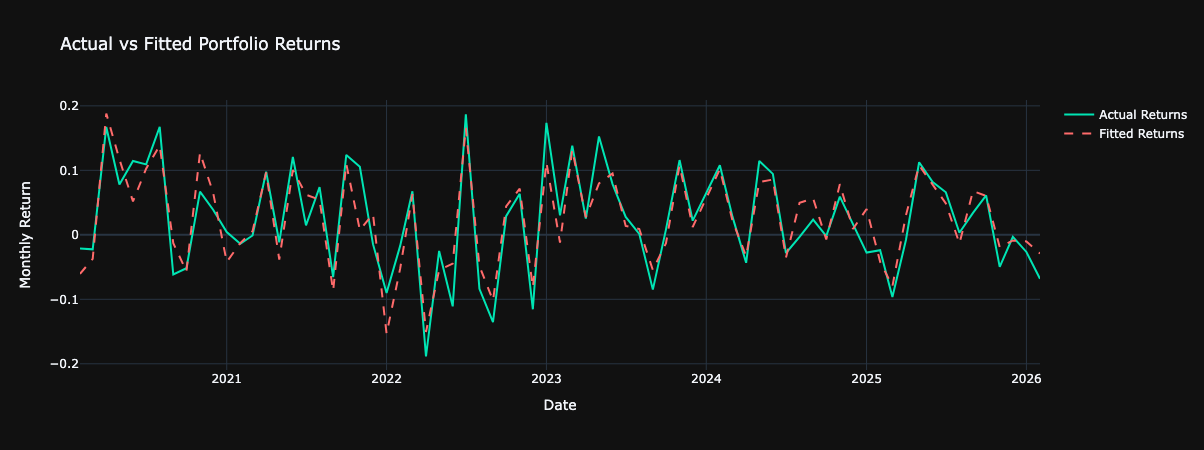

In [12]:
fitted = model.fittedvalues
actual = Y

fig2 = go.Figure()

fig2.add_trace(go.Scatter(
    x=actual.index.astype(str),
    y=actual.values,
    mode='lines',
    name='Actual Returns',
    line=dict(color='#00e5b4', width=2)
))

fig2.add_trace(go.Scatter(
    x=fitted.index.astype(str),
    y=fitted.values,
    mode='lines',
    name='Fitted Returns',
    line=dict(color='#ff6b6b', width=2, dash='dash')
))

fig2.update_layout(
    title='Actual vs Fitted Portfolio Returns',
    xaxis_title='Date',
    yaxis_title='Monthly Return',
    template='plotly_dark',
    height=450,
    hovermode='x unified'
)

fig2.show()

1. **Data Preparation**:
   - `fitted = model.fittedvalues` - Extracts the fitted/predicted values from a previously defined model
   - `actual = Y` - References the actual return values (likely defined earlier)

2. **Creating the Figure**:
   - `fig2 = go.Figure()` - Initializes a new Plotly graph object

3. **Adding the First Trace (Actual Returns)**:
   - Creates a line plot for actual returns
   - Uses `x=actual.index.astype(str)` for dates on x-axis
   - Uses `y=actual.values` for return values on y-axis
   - Sets line color to teal (`#00e5b4`) with width of 2 pixels
   - Labels this series as "Actual Returns" in the legend

4. **Adding the Second Trace (Fitted Returns)**:
   - Creates a line plot for model-fitted returns
   - Uses the same x-axis dates but with fitted values
   - Sets line color to red (`#ff6b6b`) with width of 2 pixels
   - Makes this line dashed (`dash='dash'`)
   - Labels this series as "Fitted Returns" in the legend

5. **Configuring the Layout**:
   - Sets title: "Actual vs Fitted Portfolio Returns"
   - Labels axes appropriately
   - Uses dark theme (`template='plotly_dark'`)
   - Sets height to 450 pixels
   - Enables unified hover mode to show both values when hovering over a date

6. **Displaying the Figure**:
   - `fig2.show()` renders the interactive visualization

This visualization allows for easy comparison between the model's predictions and actual portfolio performance.

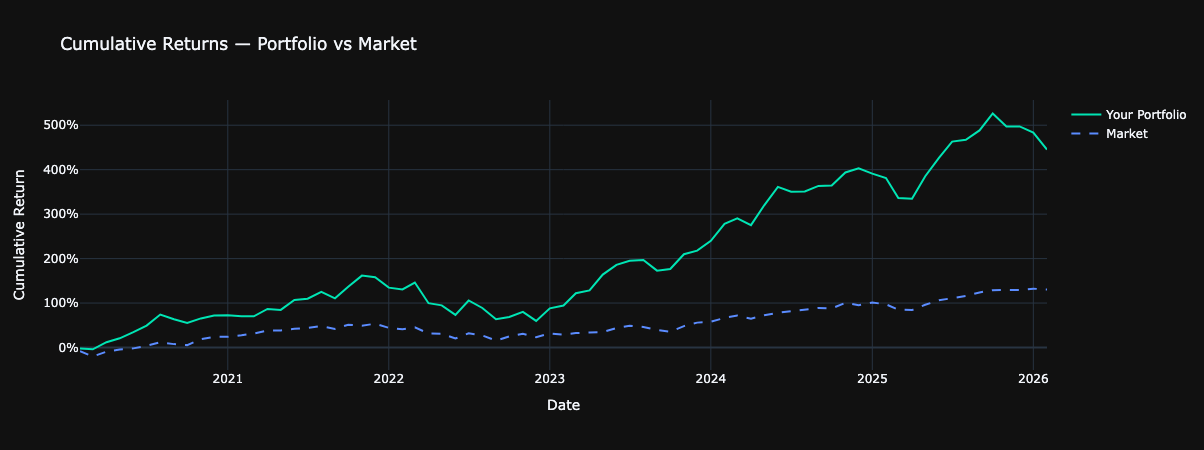

In [13]:
cumulative_portfolio = (1 + merged['Portfolio']).cumprod() - 1
cumulative_market = (1 + merged['Mkt-RF'] + merged['RF']).cumprod() - 1

fig3 = go.Figure()

fig3.add_trace(go.Scatter(
    x=merged.index.astype(str),
    y=cumulative_portfolio.values,
    mode='lines',
    name='Your Portfolio',
    line=dict(color='#00e5b4', width=2)
))

fig3.add_trace(go.Scatter(
    x=merged.index.astype(str),
    y=cumulative_market.values,
    mode='lines',
    name='Market',
    line=dict(color='#5b8cff', width=2, dash='dash')
))

fig3.update_layout(
    title='Cumulative Returns — Portfolio vs Market',
    xaxis_title='Date',
    yaxis_title='Cumulative Return',
    yaxis_tickformat='.0%',
    template='plotly_dark',
    height=450,
    hovermode='x unified'
)

fig3.show()

1. **Calculating Cumulative Returns**:
   - `cumulative_portfolio = (1 + merged['Portfolio']).cumprod() - 1`
     * Converts periodic returns to cumulative returns by adding 1 (to get return factors)
     * Applies cumulative product to calculate compounded growth
     * Subtracts 1 to convert back to percentage returns
   - `cumulative_market = (1 + merged['Mkt-RF'] + merged['RF']).cumprod() - 1`
     * Similar calculation for market returns
     * Adds risk-free rate (`RF`) back to the market excess return (`Mkt-RF`) to get total market return

2. **Creating the Figure**:
   - `fig3 = go.Figure()` - Initializes a new Plotly graph object

3. **Adding Portfolio Returns Trace**:
   - Creates a line plot for portfolio cumulative returns
   - Uses dates from the merged dataframe as x-axis values
   - Plots cumulative portfolio returns on y-axis
   - Sets line color to teal (`#00e5b4`) with width of 2 pixels
   - Labels this series as "Your Portfolio" in the legend

4. **Adding Market Returns Trace**:
   - Creates a line plot for market cumulative returns
   - Uses the same x-axis dates
   - Plots cumulative market returns on y-axis
   - Sets line color to blue (`#5b8cff`) with width of 2 pixels
   - Makes this line dashed (`dash='dash'`)
   - Labels this series as "Market" in the legend

5. **Configuring the Layout**:
   - Sets title: "Cumulative Returns — Portfolio vs Market"
   - Labels axes appropriately
   - Formats y-axis as percentages with `yaxis_tickformat='.0%'`
   - Uses dark theme (`template='plotly_dark'`)
   - Sets height to 450 pixels
   - Enables unified hover mode to show both values when hovering over a date

6. **Displaying the Figure**:
   - `fig3.show()` renders the interactive visualization

This visualization allows investors to compare how their portfolio has performed against the market over time, showing the growth of an initial investment in each.

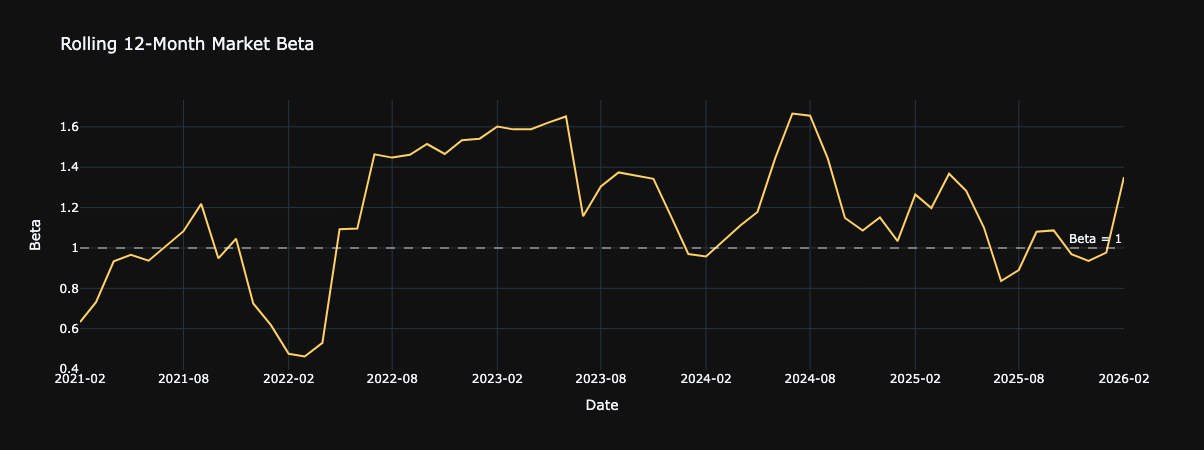

In [14]:
rolling_beta = []
rolling_dates = []

for i in range(12, len(merged)):
    window = merged.iloc[i-12:i]
    Y_roll = window['Portfolio'] - window['RF']
    X_roll = window[['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']]
    X_roll = sm.add_constant(X_roll)
    roll_model = sm.OLS(Y_roll, X_roll).fit()
    rolling_beta.append(roll_model.params['Mkt-RF'])
    rolling_dates.append(merged.index[i])

rolling_dates_str = [str(d) for d in rolling_dates]

fig4 = go.Figure()
fig4.add_trace(go.Scatter(
    x=rolling_dates_str,
    y=rolling_beta,
    mode='lines',
    name='Rolling Beta',
    line=dict(color='#ffd166', width=2)
))
fig4.add_hline(
    y=1.0,
    line_dash='dash',
    line_color='white',
    opacity=0.4,
    annotation_text='Beta = 1'
)
fig4.update_layout(
    title='Rolling 12-Month Market Beta',
    xaxis_title='Date',
    yaxis_title='Beta',
    template='plotly_dark',
    height=450,
    hovermode='x unified'
)
fig4.update_xaxes(
    tickmode='array',
    tickvals=[rolling_dates_str[i] for i in range(0, len(rolling_dates_str), 6)],
    ticktext=[rolling_dates_str[i] for i in range(0, len(rolling_dates_str), 6)]
)
fig4.show()

This code calculates and visualizes the 12-month rolling market beta of a portfolio using the Fama-French five-factor model. Here's a detailed breakdown:

1. **Rolling Beta Calculation**
- Initializes empty lists to store beta values and corresponding dates
- Loops through the data starting from the 12th observation
- For each iteration:
- Creates a 12-month rolling window of data
- Calculates excess portfolio returns (Y_roll) by subtracting risk-free rate
- Extracts the five Fama-French factors as independent variables
- Adds a constant term to the model (intercept)
- Fits an OLS regression model using statsmodels
- Extracts and stores the market beta coefficient (sensitivity to market movements)
- Records the corresponding date

2. **Visualization Setup**
- Converts date objects to strings for plotting
- Creates a new Plotly figure
- Adds a line trace for the rolling beta values with a gold color (#ffd166)

3. **Reference Line and Layout**
- Adds a horizontal reference line at Beta = 1 (market benchmark)
- A beta of 1 indicates the portfolio moves exactly with the market
- Beta > 1 indicates higher volatility than the market
- Beta < 1 indicates lower volatility than the market
- Configures the chart layout with appropriate titles and styling

4. **X-Axis Customization and Display**
- Customizes the x-axis to show only every 6th date label to avoid overcrowding
- Displays the interactive visualization

This visualization helps investors understand how their portfolio's sensitivity to market movements has changed over time, which is crucial for risk management and investment strategy adjustments.

